# EN3160: Image Processing and Machine Vision
## Assignment 1: Intensity Transformations and Neighborhood Filtering

**Department of Electronic and Telecommunication Engineering, University of Moratuwa**

* **Name:** M.R.A.Hakam
* **Index Number:** 230224V
* **GitHub Repository:** [https://github.com/hakammra/EN3160-Assignment-01](https://github.com/hakammra/EN3160-Assignment-01)

In [1]:
import os
import time
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


---
## Question 1: Piecewise Linear Intensity Transformation

### 1.1 Problem Statement & Objectives
Implement the intensity transformation depicted in Fig. 1a on the image shown in Fig. 1b  by writing a generic function:
$$\text{intensity\_transform}(\text{im}, \text{breakpoints})$$
where breakpoints are coordinates $[(r_0, s_0), (r_1, s_1), \dots, (r_n, s_n)]$.

Experiment with different breakpoints to achieve a visually pleasing output. Display the transformation curves as plots and present the original and transformed images side-by-side.

### 1.2 Mathematical Formulation
A point operation applies an intensity mapping function $s = T(r)$ to each pixel independently of its spatial coordinates. For piecewise linear transformations defined by ordered control points $(r_k, s_k)_{k=0}^N$ with $0 = r_0 < r_1 < \dots < r_N = 255$:
$$s = T(r) = s_k + \frac{s_{k+1} - s_k}{r_{k+1} - r_k}(r - r_k), \quad \text{for } r_k \le r \le r_{k+1}$$

To ensure maximum computational efficiency ($O(1)$ per pixel rather than nested evaluation), we construct a 256-element Look-Up Table (LUT) $\mathbf{t} \in \{0, \dots, 255\}^{256}$ using linear interpolation and apply it using OpenCV's cv.LUT.


TypeError: 'SubplotSpec' object is not iterable

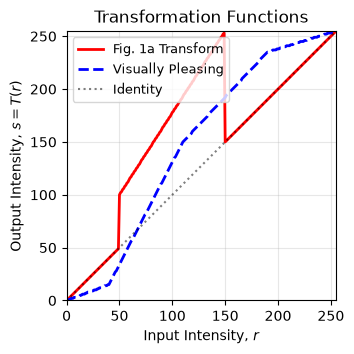

In [ ]:
def intensity_transform(im, breakpoints):

    breakpoints = np.array(breakpoints, dtype=np.float64)
    r_pts = breakpoints[:, 0]
    s_pts = breakpoints[:, 1]
    
    # Generate Look-Up Table via 1D linear interpolation with 256 levels
    lut = np.interp(np.arange(256), r_pts, s_pts)
    lut = np.clip(np.round(lut), 0, 255).astype(np.uint8)
    
    # High-performance mapping via cv.LUT
    return cv.LUT(im, lut), lut

im_q1 = cv.imread('Images/assignment/q1_emma.jpeg', cv.IMREAD_GRAYSCALE)
assert im_q1 is not None, "Failed to load Fig. 1b"

# 1. Breakpoints matching the steep contrast transformation in Fig. 1a
bp_fig1a = [[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]]

# 2. Breakpoints tuned for natural and visually pleasing dynamic range expansion
bp_pleasing = [[0, 0], [40, 15], [110, 150], [190, 235], [255, 255]]

res_fig1a, lut_fig1a = intensity_transform(im_q1, bp_fig1a)
res_pleasing, lut_pleasing = intensity_transform(im_q1, bp_pleasing)

# Display resulting images
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 1, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax0.plot(lut_fig1a, 'r-', linewidth=2, label='Fig. 1a Transform')
ax0.plot(lut_pleasing, 'b--', linewidth=2, label='Visually Pleasing')
ax0.plot([0, 255], [0, 255], 'k:', alpha=0.5, label='Identity')
ax0.set_xlabel('Input Intensity, $r$')
ax0.set_ylabel('Output Intensity, $s = T(r)$')
ax0.set_title('Transformation Functions')
ax0.set_xlim(0, 255); ax0.set_ylim(0, 255); ax0.set_aspect('equal')
ax0.legend(loc='upper left', fontsize=9); ax0.grid(True, alpha=0.3)

images = [im_q1, res_fig1a, res_pleasing]
titles = ['(a) Original', '(b) Fig. 1a Result', '(c) Visually Pleasing']
for subplot_index, (img, title) in enumerate(zip(images, titles), start=1):
    axis = fig.add_subplot(gs[subplot_index])
    axis.imshow(img, cmap='gray', vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis('off')

plt.tight_layout()
plt.show()
